EDA FOR PREPROCESSING THE IMAGES 

In [61]:
import os 
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from PIL import Image
import hashlib


In [47]:
#CONFIGURATION

BASE_DIR  = os.path.dirname(os.getcwd()) 
DATA_DIR = os.path.join(BASE_DIR,"data", "raw", "brain-tumor-dataset")



In [48]:
brain_tumor_class_counts = {}


for cls in os.listdir(DATA_DIR):
    brain_tumor_class_counts[cls] = len(os.listdir(os.path.join(DATA_DIR, cls)))
    




In [49]:
brain_tumor_class_counts

{'glioma': 3754, 'meningioma': 2343, 'no_tumor': 1757, 'pituitary': 2706}

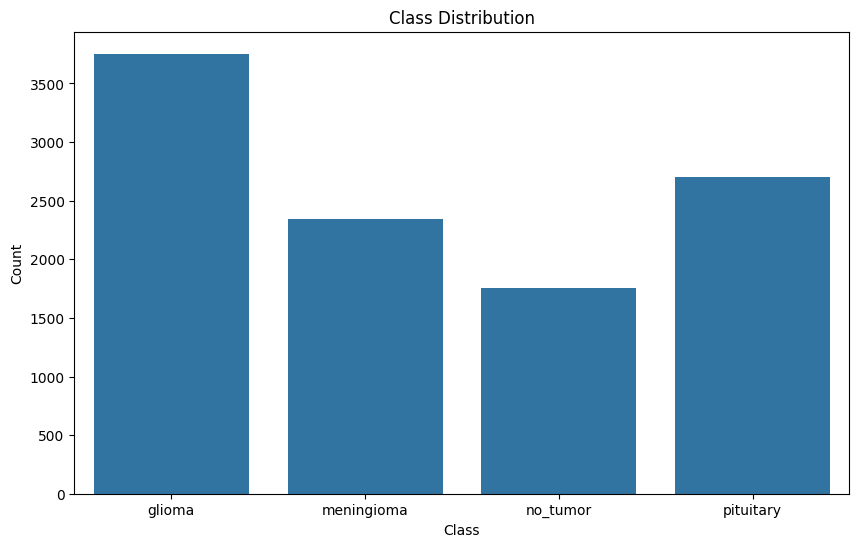

In [50]:
#bar chart with count labels
x = list(brain_tumor_class_counts.keys())
y = list(brain_tumor_class_counts.values())
plt.figure(figsize=(10,6))

sns.barplot(x= x, y=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [51]:

classes = list(brain_tumor_class_counts.keys())
counts = list(brain_tumor_class_counts.values())

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(classes),
    y=np.repeat(classes, counts)
)
weights_dict =(dict(zip(classes, weights)))
print(weights_dict)
print(f"Imbalaced Ratio: {max(counts)/min(counts)}")

{'glioma': np.float64(0.7032498668087374), 'meningioma': np.float64(1.1267605633802817), 'no_tumor': np.float64(1.5025611838360842), 'pituitary': np.float64(0.975609756097561)}
Imbalaced Ratio: 2.136596471257826


We can see the imbalaced ratio is moderatte so no need for focal loss or weighted sample we can simply use class weights and data agumentation

In [52]:
#Image resolution Analysis
def image_resolution_distibution(image_dir):
    height = []
    width = []
    for cls in os.listdir(image_dir):
        cls_dir = os.path.join(image_dir, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            with Image.open(img_path) as img:
                w, h = img.size
                width.append(w)
                height.append(h)
                return width, height

In [53]:
width, height = image_resolution_distibution(DATA_DIR)

In [54]:
print("AVG Width:", np.mean(width))
print("AVG Height:", np.mean(height))
print("Min size:", np.min(width), np.min(height))
print("Max size:", np.max(width), np.max(height))

AVG Width: 512.0
AVG Height: 512.0
Min size: 512 512
Max size: 512 512


In [55]:
#Corrupted image analysis

def count_corrupted_images(image_dir):
    bad_images = []
    
    for cls in os.listdir(image_dir):
        cls_dir = os.path.join(image_dir, cls)
        
        if not os.path.isdir(cls_dir):
            continue
        
        for image in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, image)
            try:
                with Image.open(img_path) as img:
                    img.verify()
                with Image.open(img_path) as img:
                    img.load()
            except Exception:
                bad_images.append(img_path)
    
    return len(bad_images), bad_images

In [56]:
num_of_bad_images, bad_images = count_corrupted_images(DATA_DIR)
print(f"Number of corrupted images: {num_of_bad_images}")
print(f"Corrupted image paths: {bad_images}")

Number of corrupted images: 0
Corrupted image paths: []


In [58]:
#dublicate image analysis
def check_duplicate_images(image_dir):
    hashes = set()
    duplicates = []
    
    for cls in os.listdir(image_dir):
        cls_dir = os.path.join(image_dir, cls)
        
        if not os.path.isdir(cls_dir):
            continue
        
        for image in os.listdir(cls_dir):
            image_path = os.path.join(cls_dir, image)
            try:
                with Image.open(image_path) as img:
                    img_hash = hashlib.md5(img.tobytes()).hexdigest()
                    if img_hash in hashes:
                        duplicates.append(image_path)
                    else:
                        hashes.add(img_hash)
            except Exception:
                continue
    
    return duplicates

In [60]:
duplicates = check_duplicate_images(DATA_DIR)
print(f"Number of duplicate images: {len(duplicates)}")
print(f"Duplicate image paths: {duplicates}")

Number of duplicate images: 157
Duplicate image paths: ['f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3676.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3678.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3691.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3695.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3697.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3698.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3714.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3717.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3718.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3719.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\glioma3724.jpg', 'f:\\Naman\\NeuroLens\\data\\raw\\brain-tumor-dataset\\glioma\\g

Image Quality Metrics

In [65]:
#Blur Detection(Laplacian Variance)
def blur_score(image_path):
    scores=[]
    for cls in os.listdir(image_path):
        cls_dir = os.path.join(image_path, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            image = cv2.imread(img_path,0)
            score = cv2.Laplacian(image, cv2.CV_64F).var()
            scores.append(score)
    return np.mean(scores)


In [66]:
mean = blur_score(DATA_DIR)
print(f"Average Blur Score: {mean}")

Average Blur Score: 676.2212241291925


In [ ]:
#Brighness Analysis
def brightness_score(image_path):
    scores = []
    for cls in os.listdir(image_path):
        cls_dir = os.path.join(image_path, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            image = cv2.imread(img_path,0)
            score = np.mean(image)
            scores.append(score)
    return np.mean(scores)

In [68]:
mean = brightness_score(DATA_DIR)
print(f"Average Brightness Score: {mean}")

Average Brightness Score: 50.399033111989105


In [69]:
#Contrast Analysis
def contrast_score(image_path):
    scores = []
    for cls in os.listdir(image_path):
        cls_dir = os.path.join(image_path, cls)
        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            image = cv2.imread(img_path,0)
            score = np.std(image)
            scores.append(score)
    return np.mean(scores)

In [70]:
mean = contrast_score(DATA_DIR)
print(f"Average Contrast Score: {mean}")

Average Contrast Score: 41.18798297510444


In [73]:
#Noise Analysis
def noise_level(image_path):
    scores = []
    for cls in os.listdir(image_path):
        cls_dir = os.path.join(image_path, cls)
        for image in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, image)
            img = cv2.imread(img_path, 0)
            score = np.std(cv2.GaussianBlur(img, (3,3),0) -img)
            scores.append(score)
    return np.mean(scores)

In [74]:
mean = noise_level(DATA_DIR)
print(f"Average Noise Level: {mean}")

Average Noise Level: 99.94307502742447


1. Dataset Overview

The dataset consists of brain MRI images categorized into four classes:

Glioma
Meningioma
Pituitary
No Tumor

All images are standardized to a fixed resolution of 512 × 512 pixels, ensuring uniform spatial dimensions across the dataset.

The objective of this EDA is to analyze:

Class distribution and imbalance
Image quality characteristics
Data integrity (corruption and duplicates)
Statistical properties of image intensity
2. Class Distribution and Imbalance Analysis
Observed Class Ratios (Punishing Ratio Metric)
Class	Ratio
glioma	0.70
meningioma	1.12
pituitary	0.97
no_tumor	1.50

Overall imbalance ratio: 2.13

Interpretation

The dataset exhibits moderate class imbalance. Under the punishing ratio interpretation:

no_tumor (1.50) → comparatively harder-to-learn / less frequent pattern representation
glioma (0.70) → relatively more dominant and easier to learn patterns
Other classes lie in between, indicating partial imbalance across tumor categories

This imbalance may lead to:

Biased predictions toward dominant patterns
Reduced recall for underrepresented or complex classes
Increased inter-class confusion, particularly among tumor categories
Recommended Handling Strategy

To mitigate imbalance effects during model training, the following strategies are recommended:

Class-weighted loss function (baseline approach)
Focal Loss (preferred for medical classification tasks)
Weighted random sampling to balance batch distribution
3. Image Resolution Analysis
Observations
Average image size: 512 × 512
Minimum size: 512 × 512
Maximum size: 512 × 512
Interpretation

The dataset is fully standardized in spatial resolution, eliminating the need for preprocessing related to resizing variance.

Implications for Model Design
CNN architectures can safely assume fixed input dimensions
Recommended input resizing for training efficiency:
224 × 224 (EfficientNet-B0 standard)
256 × 256 (higher detail retention option)
4. Data Quality Assessment
4.1 Corrupted Images
Number of corrupted images: 0

✔ The dataset is structurally valid with no file-level corruption detected.

4.2 Duplicate Images
Number of duplicate images: 157
Interpretation

Although no corrupted files are present, a notable number of duplicate images exist. This introduces potential risks such as:

Data leakage between training and validation sets
Artificial inflation of model performance
Reduced generalization capability
Recommended Action
Remove duplicates prior to dataset splitting
Use perceptual hashing (pHash) or image hashing techniques for detection
Ensure deduplication occurs before train-test split to avoid leakage
5. Image Intensity and Quality Statistics
Summary Metrics
Metric	Value
Average blur	676.22
Average brightness	50.40
Average contrast	41.19
Average noise level	99.94
Interpretation

The dataset exhibits characteristics typical of real-world MRI imaging:

Moderate to high noise levels
Relatively low brightness intensity
Low-to-moderate contrast variation
Noticeable blur variability across samples

These factors indicate that feature extraction may be challenging without appropriate preprocessing and augmentation.

6. Data Challenges Identified

The following challenges were identified during EDA:

Moderate class imbalance
Presence of duplicate images (157 samples)
Noisy and low-contrast image characteristics
Potential inter-class similarity in tumor categories
7. Recommended Preprocessing and Augmentation Strategy
7.1 Preprocessing Steps
Duplicate removal using perceptual hashing
Resize images to 224×224 or 256×256
Normalize pixel intensity values
7.2 Data Augmentation Strategy

To improve generalization, the following augmentation techniques are recommended:

Random rotation (±15°)
Horizontal flipping (if clinically valid)
Brightness and contrast adjustment
Gaussian noise injection
Gaussian blur (light intensity)

8. Recommended Model Training Strategy
Model Architectures
EfficientNet-B0 / B1 (recommended primary model)
ResNet50 (baseline comparison)
DenseNet121 (medical imaging robustness)
Loss Function Strategy
Focal Loss (preferred)
Weighted Cross Entropy (baseline alternative)
Imbalance Handling
Class weighting
Weighted sampling
Focal loss for harder samples
9. Summary

The dataset is well-structured and clean, with the primary challenges being:

Moderate class imbalance
Duplicate images requiring preprocessing
Noisy and low-contrast MRI characteristics

Despite these challenges, the dataset is well-suited for deep learning-based classification using transfer learning. With appropriate augmentation and loss balancing strategies, high-performance medical image classification is achievable.